#  Research Paper Recommendation System using NLP

An end-to-end semantic search engine that recommends the most relevant research papers for a natural-language query, then automatically summarizes, extracts keywords and named entities, visualizes similarity, and exports a polished PDF report.


## Objective

Given a free-text query (e.g. *"deep learning for medical image analysis"*), find the most relevant papers in a corpus of ML/AI research abstracts using sentence embeddings and vector similarity search, then enrich the top result with an AI-generated summary, extracted keywords, and named entities.

## Features

- **Semantic Search** — SentenceTransformer embeddings + FAISS for fast nearest-neighbor retrieval
- **Research Paper Recommendation** — ranks papers by cosine similarity to the query
- **AI-based Summary** — abstractive summarization with `facebook/bart-large-cnn`
- **Keyword Extraction** — KeyBERT-based keyphrase extraction
- **Named Entity Recognition** — spaCy NER over the generated summary
- **Similarity Score Visualization** — bar chart of top-k similarity scores
- **Word Cloud** — visual summary of extracted keywords
- **PDF Report Export** — a shareable one-page report per query via ReportLab


## 1. Setup & Installation

Install all dependencies used across the notebook.

In [1]:
!pip install -q datasets sentence-transformers faiss-cpu transformers==4.46.3 keybert==0.8.5 spacy rich wordcloud reportlab scikit-learn
!python -m spacy download en_core_web_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 49.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or

## 2. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import faiss

from transformers import pipeline
from keybert import KeyBERT
import spacy

from rich.console import Console
from rich.panel import Panel
from rich.table import Table as RichTable

from wordcloud import WordCloud

from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Image, Table as PDFTable, TableStyle
)
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.enums import TA_CENTER
from reportlab.lib import colors
from reportlab.lib.units import inch


## 3. Load Dataset

We use the [`CShorten/ML-ArXiv-Papers`](https://huggingface.co/datasets/CShorten/ML-ArXiv-Papers) dataset from the Hugging Face Hub.

In [3]:
dataset = load_dataset("CShorten/ML-ArXiv-Papers", split='train')
print(dataset)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/986 [00:00<?, ?B/s]

ML-Arxiv-Papers.csv:   0%|          | 0.00/147M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117592 [00:00<?, ? examples/s]

Dataset({
    features: ['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'],
    num_rows: 117592
})


In [4]:
df = pd.DataFrame(dataset)
df.head()


,Unnamed: 0.1,Unnamed: 0,title,abstract
0,0,0.0,Learning from compressed observations,The problem of statistical learning is to co...
1,1,1.0,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,2,2.0,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,3,3.0,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,4,4.0,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...


## 4. Preprocessing

Keep only the fields we need, combine title + abstract into a single field for embedding, and clean up whitespace.

In [5]:
df = df[['title', 'abstract']]
print('Shape before subsampling:', df.shape)
print('Missing values:\n', df.isnull().sum())


Shape before subsampling: (117592, 2)
Missing values:
 title       0
abstract    0
dtype: int64


In [6]:
# Use a manageable subset for this demo (increase for more coverage)
df = df.head(15000).reset_index(drop=True)

df['paper_text'] = df['title'] + ' ' + df['abstract']
df['paper_text'] = df['paper_text'].str.replace('\n', ' ', regex=False).str.strip()

print(df.shape)
df[['paper_text']].head()


(15000, 3)


,paper_text
0,Learning from compressed observations The pr...
1,Sensor Networks with Random Links: Topology De...
2,The on-line shortest path problem under partia...
3,A neural network approach to ordinal regressio...
4,Parametric Learning and Monte Carlo Optimizati...


## 5. Load Sentence Embedding Model

We use [`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), a lightweight, fast sentence-transformer that produces 384-dimensional embeddings.

In [7]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
# Quick sanity check on a single sample
sample_text = df['paper_text'].iloc[0]
embedding = model.encode(sample_text)
print(type(embedding), embedding.shape)


<class 'numpy.ndarray'> (384,)


## 6. Generate Embeddings for the Full Corpus

Embeddings are cached to disk (`paper_embeddings.npy`) so re-running the notebook doesn't recompute them.

In [9]:
import os
import numpy as np
if os.path.exists("paper_embeddings.npy"):
    print("Loading saved embeddings")
    embedding = np.load("paper_embeddings.npy")
else:
    print("Generating embeddings")
    embedding = model.encode(
        df["paper_text"].tolist(),
        batch_size=32,
        show_progress_bar=True
    )
    np.save("paper_embeddings.npy", embedding)
    print("Embeddings saved successfully!")

Loading saved embeddings


## 7. Build the FAISS Similarity Index

Embeddings are L2-normalized so that inner product search is equivalent to cosine similarity. The index is also cached to disk.

In [10]:
if os.path.exists("paper_faiss.index"):
    print("Loading existing FAISS index")
    index = faiss.read_index("paper_faiss.index")
else:
    print("Creating new FAISS index")
    faiss.normalize_L2(embedding)
    index = faiss.IndexFlatIP(embedding.shape[1])
    index.add(embedding)
    faiss.write_index(index, "paper_faiss.index")

print("Total vectors indexed:", index.ntotal)


Creating new FAISS index
Total vectors indexed: 15000


## 8. Semantic Search Function

In [11]:
def search_paper(query, k=5):
    """Return (distances, indices) of the top-k most similar papers to `query`."""
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, k)
    return D, I


In [12]:
D, I = search_paper("deep learning for medical image analysis")
print("Scores:", D)
print("Indices:", I)
print()
print(df.iloc[I[0][0]]["title"])


Scores: [[0.6807244  0.67092204 0.65219975 0.62811744 0.61311525]]
Indices: [[10466 13730 11873 12691 11282]]

A Perspective on Deep Imaging


## 9. AI-Based Summarization

We use Facebook's `bart-large-cnn` model for abstractive summarization of the retrieved abstract.

In [13]:
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [14]:
sample_summary = summarizer(df.iloc[I[0][0]]["abstract"], max_length=120, min_length=40, do_sample=False)
print(sample_summary[0]["summary_text"])


The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.


## 10. Keyword Extraction (KeyBERT)

In [15]:
kw_model = KeyBERT(model)  # reuse the same embedding model to avoid loading a second one


In [16]:
sample_keywords = kw_model.extract_keywords(
    df.iloc[I[0][0]]["abstract"], keyphrase_ngram_range=(1, 3), stop_words="english"
)
print(sample_keywords)


[('tomographic imaging deep', 0.6704), ('imaging deep learning', 0.6543), ('learning medical imaging', 0.6041), ('imaging deep', 0.5919), ('medical imaging', 0.5281)]


## 11. Named Entity Recognition (spaCy)

In [17]:
ner_model = spacy.load("en_core_web_sm")
print("NER model loaded successfully")


NER model loaded successfully


In [18]:
def extract_entities(text):
    """Return a list of (entity_text, entity_label) tuples found in `text`."""
    doc = ner_model(text)
    return [(ent.text, ent.label_) for ent in doc.ents]


In [19]:
sample = """
Google developed BERT using PyTorch in California.
Microsoft released GPT.
Research was conducted in India.
"""

print(extract_entities(sample))

[('Google', 'ORG'), ('BERT', 'ORG'), ('PyTorch', 'ORG'), ('California', 'GPE'), ('Microsoft', 'ORG'), ('GPT', 'ORG'), ('India', 'GPE')]


## 12. Rich Console Output

`rich` gives us nicely formatted panels and tables for terminal/notebook output.

In [20]:
console = Console()
print("Rich console ready")


Rich console ready


## 13. PDF Report Export

Builds a shareable one-page PDF report for a given query: recommended paper, summary, entities, keywords, similarity chart, and word cloud.

In [21]:
def export_pdf(query,title,score,abstract,summary,entities,keywords):

    styles = getSampleStyleSheet()

    title_style = styles["Heading1"]
    title_style.alignment = TA_CENTER

    heading = styles["Heading2"]
    normal = styles["BodyText"]

    safe_query = query.replace(" ", "_")

    doc = SimpleDocTemplate(
    f"Research_Report_{safe_query}.pdf")

    story = []

    # -------------------------------
    # Title
    # -------------------------------

    story.append(Paragraph("AI-Based Research Paper Recommendation System", title_style))
    story.append(Spacer(1,0.3*inch))

    # -------------------------------
    # Query
    # -------------------------------

    story.append(Paragraph(f"<b>Query :</b> {query}",normal))
    story.append(Spacer(1,0.15*inch))

    # -------------------------------
    # Title
    # -------------------------------

    story.append(Paragraph("<b>Recommended Research Paper</b>",heading))
    story.append(Paragraph(title,normal))
    story.append(Spacer(1,0.15*inch))

    # -------------------------------
    # Similarity
    # -------------------------------

    story.append(
        Paragraph(
            f"<b>Similarity Score :</b> {score:.4f}",
            normal
        )
    )

    story.append(Spacer(1,0.25*inch))

    # -------------------------------
    # Abstract
    # -------------------------------

    story.append(Paragraph("Abstract",heading))
    story.append(Paragraph(abstract,normal))
    story.append(Spacer(1,0.25*inch))

    # -------------------------------
    # AI Summary
    # -------------------------------

    story.append(Paragraph("Generated Summary",heading))
    story.append(Paragraph(summary,normal))
    story.append(Spacer(1,0.25*inch))

    # -------------------------------
    # Named Entities
    # -------------------------------

    story.append(Paragraph("Detected Named Entities",heading))

    if len(entities)==0:

        story.append(
            Paragraph(
                "No Named Entities Found",
                normal
            )
        )

    else:

        data=[["Entity","Label"]]

        for e,l in entities:
            data.append([e,l])

        table = PDFTable(data,colWidths=[3*inch,2*inch])

        table.setStyle(
            TableStyle([
                ("BACKGROUND",(0,0),(-1,0),colors.darkblue),
                ("TEXTCOLOR",(0,0),(-1,0),colors.white),
                ("GRID",(0,0),(-1,-1),1,colors.black),
                ("BACKGROUND",(0,1),(-1,-1),colors.beige),
                ("ALIGN",(0,0),(-1,-1),"CENTER"),
                ("BOTTOMPADDING",(0,0),(-1,0),8),
            ])
        )

        story.append(table)

    story.append(Spacer(1,0.3*inch))

    # -------------------------------
    # Keywords
    # -------------------------------

    story.append(Paragraph("Important Keywords",heading))

    keyword_data=[["Keyword","Score"]]

    for k,s in keywords:
        keyword_data.append(
            [
                k,
                f"{s:.3f}"
            ]
        )

    keyword_table = PDFTable(
        keyword_data,
        colWidths=[4.5*inch,1*inch]
    )

    keyword_table.setStyle(
        TableStyle([
            ("BACKGROUND",(0,0),(-1,0),colors.green),
            ("TEXTCOLOR",(0,0),(-1,0),colors.white),
            ("GRID",(0,0),(-1,-1),1,colors.black),
            ("BACKGROUND",(0,1),(-1,-1),colors.whitesmoke),
            ("ALIGN",(0,0),(-1,-1),"CENTER"),
            ("BOTTOMPADDING",(0,0),(-1,0),8),
        ])
    )

    story.append(keyword_table)

    story.append(Spacer(1,0.35*inch))

    # -------------------------------
    # Similarity Score Graph
    # -------------------------------

    story.append(Paragraph("Similarity Score Analysis", heading))
    story.append(Spacer(1,0.15*inch))

    try:
        graph = Image("similarity_graph.png")
        graph.drawWidth = 6.2 * inch
        graph.drawHeight = 3.8 * inch
        story.append(graph)
    except:
        story.append(Paragraph("Graph image not found.", normal))

    story.append(Spacer(1,0.30*inch))

    # -------------------------------
    # Word Cloud
    # -------------------------------

    story.append(Paragraph("Keyword Distribution", heading))
    story.append(Spacer(1,0.15*inch))

    try:
        cloud = Image("wordcloud.png")
        cloud.drawWidth = 6.2 * inch
        cloud.drawHeight = 3.8 * inch
        story.append(cloud)
    except:
        story.append(Paragraph("WordCloud image not found.", normal))

    story.append(Spacer(1,0.30*inch))

    # -------------------------------
    # Footer
    # -------------------------------

    story.append(
        Paragraph(
            "<font size=9 color=grey>"
            "Generated using AI Research Paper Recommendation System"
            "Developed by Soham Mahure"
            "</font>",
            normal
        )
    )

    # -------------------------------
    # Build PDF
    # -------------------------------

    doc.build(story)

    print("-"*60)
    print("PDF Generated Successfully")
    print("File Name : Research_Report.pdf")
    print("-"*60)

## 14. End-to-End Pipeline: Search → Summarize → Analyze → Export

This ties every component together into a single call.

In [22]:
def search_and_summarize(query, k=5):

    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    D, I = index.search(query_embedding, k)

    best_idx = I[0][0]
    best_score = D[0][0]

    score = best_score
    idx = best_idx

    console.print(
        Panel.fit(
            f"""
 TOP RECOMMENDED PAPER

Title :
{df.iloc[idx]["title"]}

Similarity Score :
{score:.4f}
""",
            title="Top Recommended Paper",
            border_style="bright_green"
        )
    )

    print("Research Abstract")
    print(df.iloc[idx]["abstract"][:500])
    print()

    summary = summarizer(
        df.iloc[idx]["abstract"],
        max_length=120,
        min_length=40,
        do_sample=False
    )

    console.print(
        Panel(
            summary[0]["summary_text"],
            title="AI Generated Summary",
            border_style="green"
        )
    )

    print()

    # -----------------------------
    # Named Entity Recognition
    # -----------------------------

    entities = extract_entities(summary[0]["summary_text"])

    print("=" * 60)
    print("Detected Named Entities")
    print("=" * 60)

    if len(entities) == 0:
        print("No Named Entities Found")
    else:
        for entity, label in entities:
            print(f"{entity:<30} | {label}")

    print()

    # -----------------------------
    # Keyword Extraction
    # -----------------------------

    text = summary[0]["summary_text"]

    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 3),
        stop_words="english"
    )

    table = RichTable(title="🏷 Extracted Keywords")

    table.add_column("Keyword", style="cyan")
    table.add_column("Score", style="green")

    for kword, score in keywords:
        table.add_row(kword, f"{score:.3f}")

    print("Top Important Keywords")

    # -----------------------------
    # Similarity Score Graph
    # -----------------------------

    import matplotlib.pyplot as plt

    paper_no = list(range(1, len(D[0]) + 1))
    scores = D[0]

    plt.figure(figsize=(8, 5))

    plt.bar(
        paper_no,
        scores,
        color="skyblue",
        edgecolor="black"
    )

    plt.xlabel("Paper Rank")
    plt.ylabel("Similarity Score")
    plt.title("Similarity Analysis of Recommended Papers")

    plt.xticks(paper_no)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    for i, s in enumerate(scores):
        plt.text(
            i + 1,
            s + 0.003,
            f"{s:.2f}",
            ha="center"
        )
    plt.tight_layout()
    plt.savefig("similarity_graph.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.close()
    print("\n")
    print("="*80)
    print("\n")

    # -----------------------------
    # Word Cloud
    # -----------------------------

    from wordcloud import WordCloud

    word_text = " ".join([k for k, s in keywords])

    wc = WordCloud(
        width=900,
        height=450,
        background_color="white",
        colormap="viridis"
    ).generate(word_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Most Relevant Keywords")
    plt.savefig("wordcloud.png", dpi=300, bbox_inches="tight")
    plt.show()

    export_pdf(
    query,
    df.iloc[idx]["title"],
    best_score,
    df.iloc[idx]["abstract"],
    summary[0]["summary_text"],
    entities,
    keywords
)

## 15. Demo

Run a few example queries end-to-end.


╭─────────────────────── Top Recommended Paper ────────────────────────╮
│                                                                      │
│  TOP RECOMMENDED PAPER                                               │
│                                                                      │
│ Title :                                                              │
│ Implementation of deep learning algorithm for automatic detection of │
│   brain tumors using intraoperative IR-thermal mapping data          │
│                                                                      │
│ Similarity Score :                                                   │
│ 0.6452                                                               │
│                                                                      │
╰──────────────────────────────────────────────────────────────────────╯

Research Abstract
  The efficiency of deep machine learning for automatic delineation of tumor
areas has been demonstrated for intraoperative neuronavigation using active
IR-mapping with the use of the cold test. The proposed approach employs a
matrix IR-imager to remotely register the space-time distribution of surface
temperature pattern, which is determined by the dynamics of local cerebral
blood flow. The advantages of this technique are non-invasiveness, zero risks
for the health of patients and medical staf



╭───────────────────────────────────────────── AI Generated Summary ──────────────────────────────────────────────╮
│ The efficiency of deep machine learning has been demonstrated for intraoperative neuronavigation using          │
│ activeIR-mapping with the use of the cold test. The advantages of this technique are non-invasiveness, zero     │
│ risks for health of patients and medical staff, low implementation and operational costs, ease and speed of     │
│ use.                                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Detected Named Entities
activeIR                       | ORG
zero                           | CARDINAL

Top Important Keywords


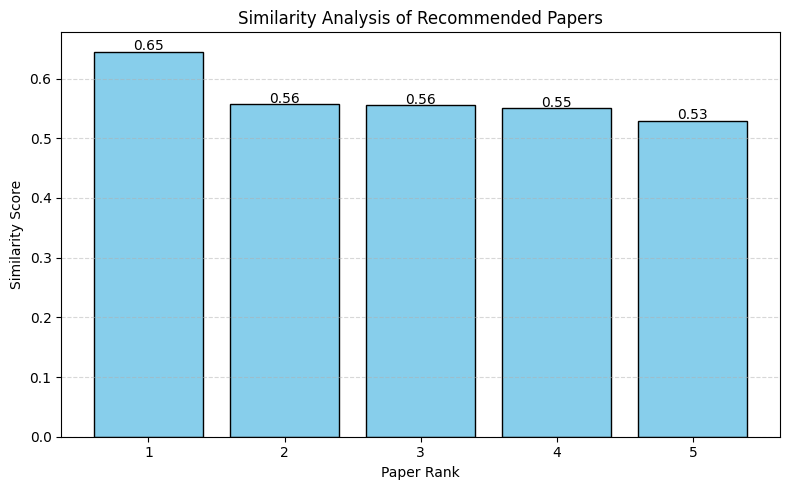

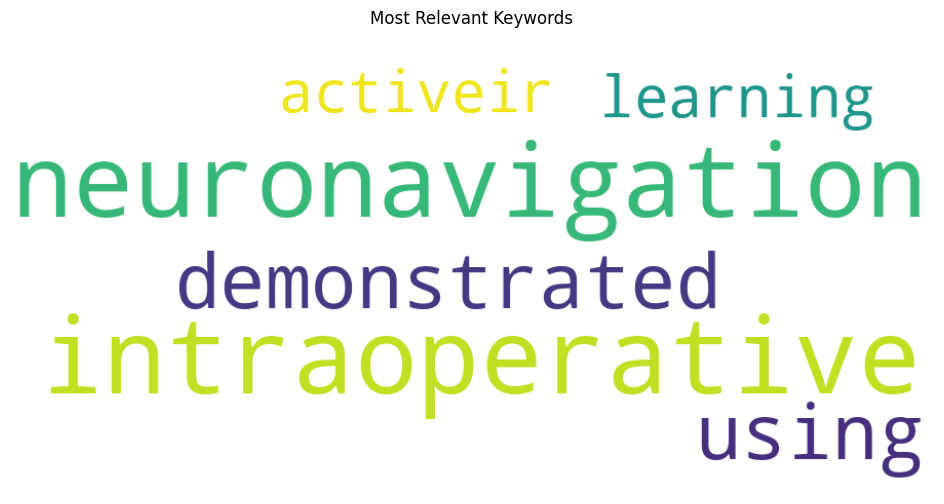

------------------------------------------------------------
PDF Generated Successfully
File Name : Research_Report.pdf
------------------------------------------------------------


In [24]:
search_and_summarize("Brain Tumor Detection using Deep Learning", k=5)

╭──── Top Recommended Paper ────╮
│                               │
│  TOP RECOMMENDED PAPER        │
│                               │
│ Title :                       │
│ A Perspective on Deep Imaging │
│                               │
│ Similarity Score :            │
│ 0.7355                        │
│                               │
╰───────────────────────────────╯

Research Abstract
  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance



╭───────────────────────────────────────────── AI Generated Summary ──────────────────────────────────────────────╮
│ The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only     │
│ image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain   │
│ knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical    │
│ applications.                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Detected Named Entities
No Named Entities Found

Top Important Keywords


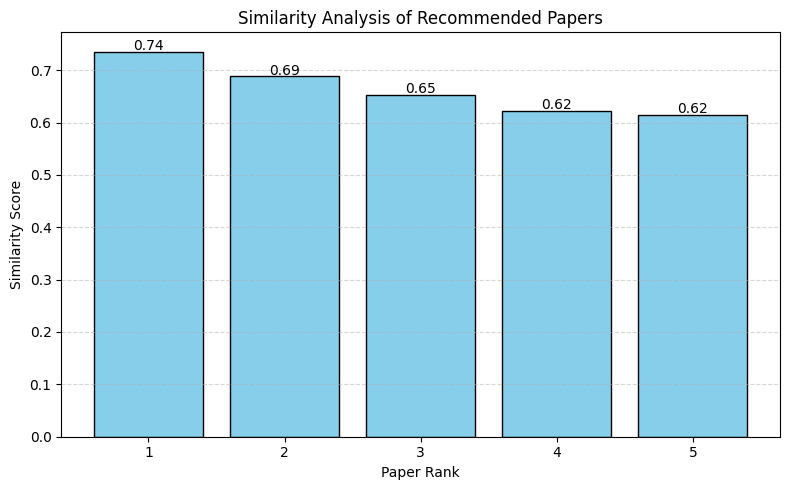

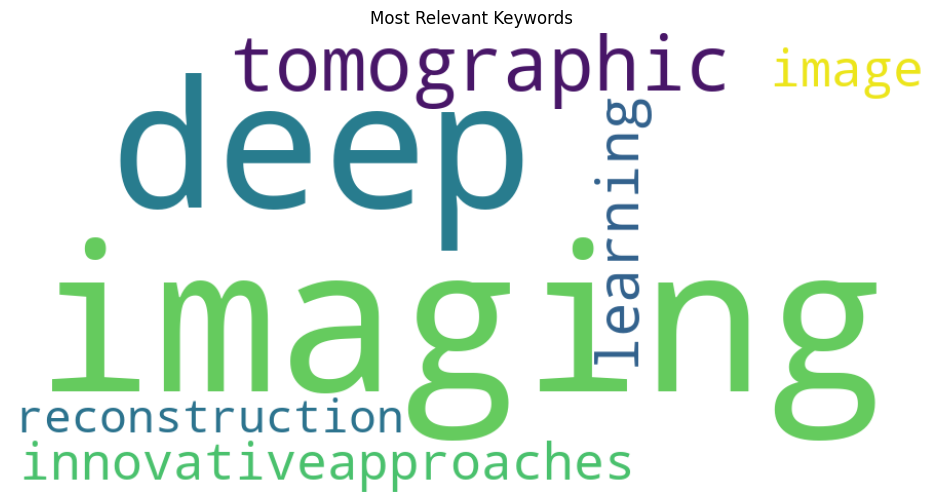

------------------------------------------------------------
PDF Generated Successfully
File Name : Research_Report.pdf
------------------------------------------------------------


In [23]:
search_and_summarize("Deep learning in medical imaging" , k = 5 )

╭───────────────── Top Recommended Paper ──────────────────╮
│                                                          │
│  TOP RECOMMENDED PAPER                                   │
│                                                          │
│ Title :                                                  │
│ Automatic Breast Ultrasound Image Segmentation: A Survey │
│                                                          │
│ Similarity Score :                                       │
│ 0.5632                                                   │
│                                                          │
╰──────────────────────────────────────────────────────────╯

Research Abstract
  Breast cancer is one of the leading causes of cancer death among women
worldwide. In clinical routine, automatic breast ultrasound (BUS) image
segmentation is very challenging and essential for cancer diagnosis and
treatment planning. Many BUS segmentation approaches have been studied in the
last two decades, and have been proved to be effective on private datasets.
Currently, the advancement of BUS image segmentation seems to meet its
bottleneck. The improvement of the performance is increasi



╭───────────────────────────────────────────── AI Generated Summary ──────────────────────────────────────────────╮
│ Breast cancer is one of the leading causes of cancer death among women worldwide. In clinical routine,          │
│ automatic breast ultrasound (BUS) image segmentation is very challenging and essential for cancer diagnosis.    │
│ Many BUS segmentation approaches have been studied in the last two decades.                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Detected Named Entities
Breast                         | ORG
the last two decades           | DATE

Top Important Keywords


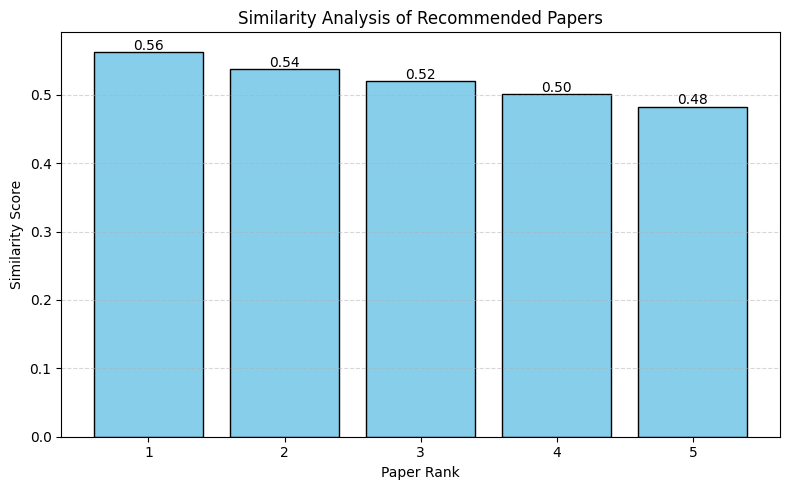

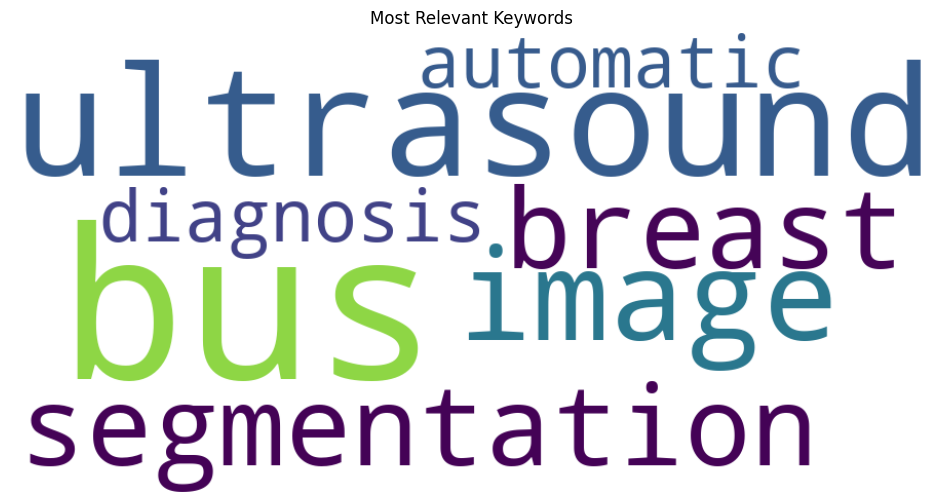

------------------------------------------------------------
PDF Generated Successfully
File Name : Research_Report.pdf
------------------------------------------------------------


In [25]:
search_and_summarize("Medical Image Segmentation", k=5)